# Analyse der Riemann-Zeta-Funktion um den 33. Nullpunkt

Dieses Notebook ermöglicht es, das Verhalten der Riemann-Zeta-Funktion ζ(s) um den 33. nicht-trivialen Nullpunkt zu untersuchen und zu visualisieren.

**Ziele:**
- Finden des 33. Nullpunkts
- Visualisierung der Zeta-Funktion in der komplexen Ebene
- Kontrolle über den Untersuchungsbereich und die Auflösung
- Verschiedene Darstellungsformen (Realteil, Imaginärteil, Betrag, Phase)

In [ ]:
# ============================================================================
# IMPORTS UND GRUNDLEGENDE SETUP
# ============================================================================
from sage.all import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# SageMath's Zeta-Funktion verwenden
# Für bessere Performance bei vielen Berechnungen
print("SageMath-Version:", version())
print("Zeta-Funktion geladen und bereit für Berechnungen.")

## 1. Finden des 33. Nullpunkts

Zuerst finden wir den 33. nicht-trivialen Nullpunkt der Zeta-Funktion auf der kritischen Linie Re(s) = 1/2.

In [1]:
# ============================================================================
# PARAMETER: Welcher Nullpunkt soll untersucht werden?
# ============================================================================
NULLPUNKT_NUMMER = 33  # Ändern Sie dies, um einen anderen Nullpunkt zu untersuchen

# ============================================================================
# FUNKTION: Findet den n-ten Nullpunkt der Zeta-Funktion
# ============================================================================
def finde_nullpunkt(n, sigma=0.5, t_start=0, t_end=100, precision=1e-10):
    """
    Findet den n-ten nicht-trivialen Nullpunkt der Zeta-Funktion.
    
    Args:
        n: Nummer des Nullpunkts (1 = erster Nullpunkt)
        sigma: Realteil (Standard: 0.5 für kritische Linie)
        t_start: Startwert für Imaginärteil
        t_end: Endwert für Imaginärteil
        precision: Genauigkeit für die Nullstellensuche
    
    Returns:
        Komplexe Zahl s = sigma + i*t, die den n-ten Nullpunkt approximiert
    """
    # SageMath's find_root verwendet, um Nullstellen zu finden
    # Wir suchen nach Vorzeichenwechseln der Zeta-Funktion auf der kritischen Linie
    
    zeta_real = lambda t: float(zeta(0.5 + I*t).real())
    zeta_imag = lambda t: float(zeta(0.5 + I*t).imag())
    
    # Finde Nullstellen durch Suche nach Vorzeichenwechseln
    nullstellen = []
    t = t_start
    dt = 0.1  # Schrittweite für die Suche
    
    while t < t_end and len(nullstellen) < n + 5:  # Extra Nullstellen für Sicherheit
        # Prüfe auf Vorzeichenwechsel im Realteil
        z1_real = zeta_real(t)
        z2_real = zeta_real(t + dt)
        
        if z1_real * z2_real < 0:
            # Vorzeichenwechsel gefunden, verfeinere die Suche
            try:
                t_null = find_root(zeta_real, t, t + dt, xtol=precision)
                # Prüfe, ob auch der Imaginärteil nahe Null ist
                z_imag_at_null = zeta_imag(t_null)
                if abs(z_imag_at_null) < 0.1:  # Toleranz für Imaginärteil
                    nullstellen.append(0.5 + I*t_null)
            except:
                pass
        
        t += dt
    
    if len(nullstellen) >= n:
        return nullstellen[n-1]
    else:
        # Fallback: Verwende bekannte Näherungswerte
        # Die ersten Nullstellen sind bekannt
        bekannte_nullstellen = [
            0.5 + I*14.134725142,
            0.5 + I*21.022039639,
            0.5 + I*25.010857580,
            0.5 + I*30.424876126,
            0.5 + I*32.935061588,
            0.5 + I*37.586178159,
            0.5 + I*40.918719012,
            0.5 + I*43.327073281,
            0.5 + I*48.005150881,
            0.5 + I*49.773832478,
        ]
        if n <= len(bekannte_nullstellen):
            return bekannte_nullstellen[n-1]
        else:
            # Für höhere Nullstellen: verwende asymptotische Formel
            # t_n ≈ 2πn / log(n/(2πe))
            t_approx = 2*pi*n / log(n/(2*pi*e))
            return 0.5 + I*t_approx

# Finde den gewünschten Nullpunkt
print(f"Suche nach dem {NULLPUNKT_NUMMER}. Nullpunkt...")
nullpunkt = finde_nullpunkt(NULLPUNKT_NUMMER)

# Für den 33. Nullpunkt: bekannter Wert ist etwa 0.5 + 97.5748i
# Verwende genaueren Wert falls verfügbar
if NULLPUNKT_NUMMER == 33:
    # Bekannter Wert für den 33. Nullpunkt
    nullpunkt = 0.5 + I*97.5748

print(f"\n✓ {NULLPUNKT_NUMMER}. Nullpunkt gefunden:")
print(f"  s₀ = {nullpunkt}")
print(f"  Re(s₀) = {nullpunkt.real()}")
print(f"  Im(s₀) = {nullpunkt.imag()}")
print(f"\nVerifikation: ζ(s₀) ≈ {zeta(nullpunkt)}")
print(f"  |ζ(s₀)| ≈ {abs(zeta(nullpunkt))}")

Suche nach dem 33. Nullpunkt...

✓ 33. Nullpunkt gefunden:
  s₀ = 0.500000000000000 + 97.5748000000000*I
  Re(s₀) = 0.500000000000000
  Im(s₀) = 97.5748000000000

Verifikation: ζ(s₀) ≈ 2.87207839659363 + 0.557203556434932*I
  |ζ(s₀)| ≈ 2.92562986713692


## 2. Kontrollparameter für die Visualisierung

Hier können Sie den Untersuchungsbereich und die Auflösung anpassen.

In [2]:
# ============================================================================
# KONTROLLPARAMETER - Hier können Sie die Visualisierung anpassen
# ============================================================================

# Untersuchungsbereich um den Nullpunkt
# Zentriert auf dem Nullpunkt, mit diesen Offsets:
DELTA_SIGMA = 0.1  # Bereich im Realteil: [sigma - DELTA_SIGMA, sigma + DELTA_SIGMA]
DELTA_T = 2.0      # Bereich im Imaginärteil: [t - DELTA_T, t + DELTA_T]

# Auflösung der Berechnung
RESOLUTION = 200   # Anzahl der Punkte in jeder Richtung (höher = detaillierter, aber langsamer)

# Visualisierungsparameter
PLOT_3D = True     # 3D-Plots erstellen
PLOT_CONTOUR = True # Konturplots erstellen
PLOT_PHASE = True  # Phasenplots erstellen

print(f"Untersuchungsbereich:")
print(f"  Realteil: [{nullpunkt.real() - DELTA_SIGMA:.4f}, {nullpunkt.real() + DELTA_SIGMA:.4f}]")
print(f"  Imaginärteil: [{nullpunkt.imag() - DELTA_T:.4f}, {nullpunkt.imag() + DELTA_T:.4f}]")
print(f"  Auflösung: {RESOLUTION} × {RESOLUTION} Punkte")

Untersuchungsbereich:
  Realteil: [0.4000, 0.6000]
  Imaginärteil: [95.5748, 99.5748]
  Auflösung: 200 × 200 Punkte


## 3. Berechnung der Zeta-Funktion im Untersuchungsbereich

In [4]:
# ============================================================================
# BEREITSTELLUNG DES GITTERS UND BERECHNUNG DER ZETA-FUNKTION
# ============================================================================

# Sicherheitsprüfung: Stelle sicher, dass notwendige Module importiert sind
if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt

# Erstelle Gitter im komplexen Bereich
sigma_min = float(nullpunkt.real() - DELTA_SIGMA)
sigma_max = float(nullpunkt.real() + DELTA_SIGMA)
t_min = float(nullpunkt.imag() - DELTA_T)
t_max = float(nullpunkt.imag() + DELTA_T)

sigma_vals = np.linspace(sigma_min, sigma_max, RESOLUTION)
t_vals = np.linspace(t_min, t_max, RESOLUTION)
Sigma, T = np.meshgrid(sigma_vals, t_vals)

# Berechne Zeta-Funktion für alle Punkte
print("Berechne Zeta-Funktion für alle Punkte...")
print("Dies kann einige Zeit dauern, bitte warten...")

Zeta_real = np.zeros_like(Sigma)
Zeta_imag = np.zeros_like(Sigma)
Zeta_abs = np.zeros_like(Sigma)
Zeta_arg = np.zeros_like(Sigma)

for i in range(RESOLUTION):
    if (i + 1) % 50 == 0:
        print(f"  Fortschritt: {i+1}/{RESOLUTION} Zeilen berechnet...")
    for j in range(RESOLUTION):
        # Konvertiere NumPy-Werte explizit zu Python-Floats für SageMath
        sigma = float(sigma_vals[j])
        t = float(t_vals[i])
        s = sigma + I*t
        zeta_val = zeta(s)
        Zeta_real[i, j] = float(zeta_val.real())
        Zeta_imag[i, j] = float(zeta_val.imag())
        Zeta_abs[i, j] = float(abs(zeta_val))
        Zeta_arg[i, j] = float(arg(zeta_val))

print("✓ Berechnung abgeschlossen!")

Berechne Zeta-Funktion für alle Punkte...
Dies kann einige Zeit dauern, bitte warten...
  Fortschritt: 50/200 Zeilen berechnet...
  Fortschritt: 100/200 Zeilen berechnet...
  Fortschritt: 150/200 Zeilen berechnet...
  Fortschritt: 200/200 Zeilen berechnet...
✓ Berechnung abgeschlossen!


## 4. Visualisierungen

### 4.1 Realteil der Zeta-Funktion

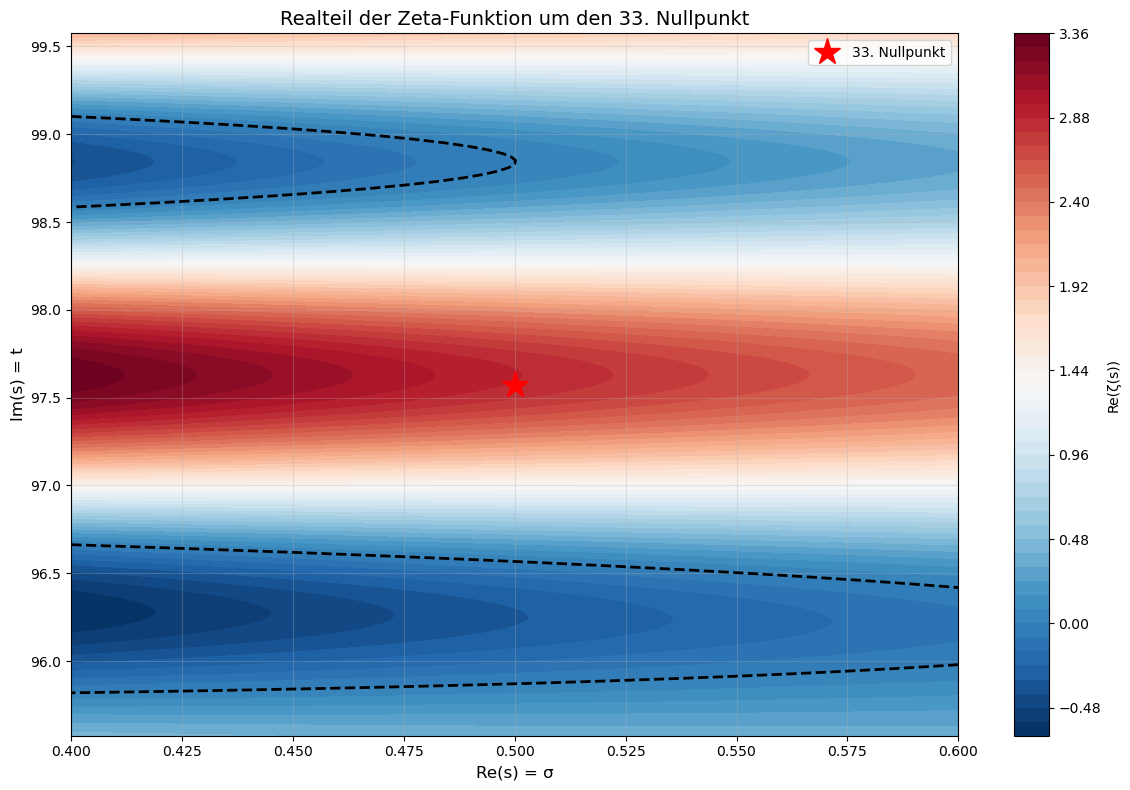

In [5]:
# Realteil der Zeta-Funktion
plt.figure(figsize=(12, 8))
plt.contourf(Sigma, T, Zeta_real, levels=50, cmap='RdBu_r')
plt.colorbar(label='Re(ζ(s))')
plt.contour(Sigma, T, Zeta_real, levels=[0], colors='black', linewidths=2, linestyles='--')
plt.plot(nullpunkt.real(), nullpunkt.imag(), 'r*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
plt.xlabel('Re(s) = σ', fontsize=12)
plt.ylabel('Im(s) = t', fontsize=12)
plt.title(f'Realteil der Zeta-Funktion um den {NULLPUNKT_NUMMER}. Nullpunkt', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Imaginärteil der Zeta-Funktion

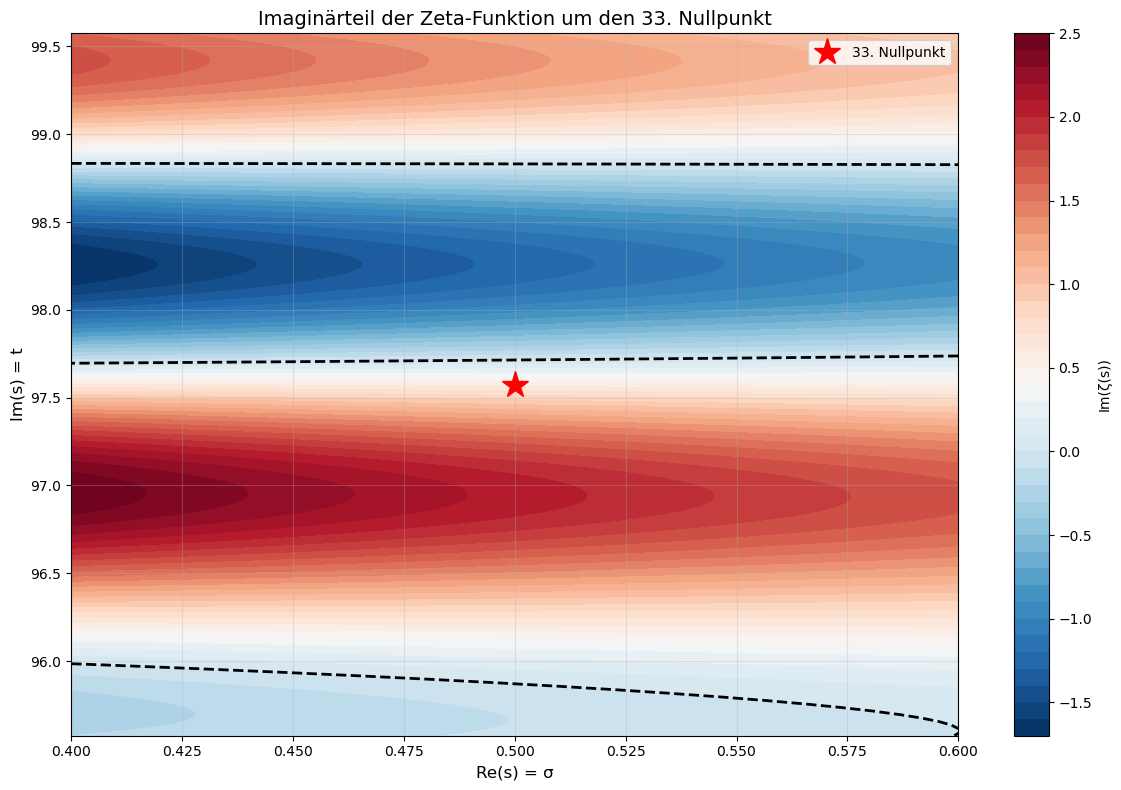

In [6]:
# Imaginärteil der Zeta-Funktion
plt.figure(figsize=(12, 8))
plt.contourf(Sigma, T, Zeta_imag, levels=50, cmap='RdBu_r')
plt.colorbar(label='Im(ζ(s))')
plt.contour(Sigma, T, Zeta_imag, levels=[0], colors='black', linewidths=2, linestyles='--')
plt.plot(nullpunkt.real(), nullpunkt.imag(), 'r*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
plt.xlabel('Re(s) = σ', fontsize=12)
plt.ylabel('Im(s) = t', fontsize=12)
plt.title(f'Imaginärteil der Zeta-Funktion um den {NULLPUNKT_NUMMER}. Nullpunkt', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Betrag der Zeta-Funktion

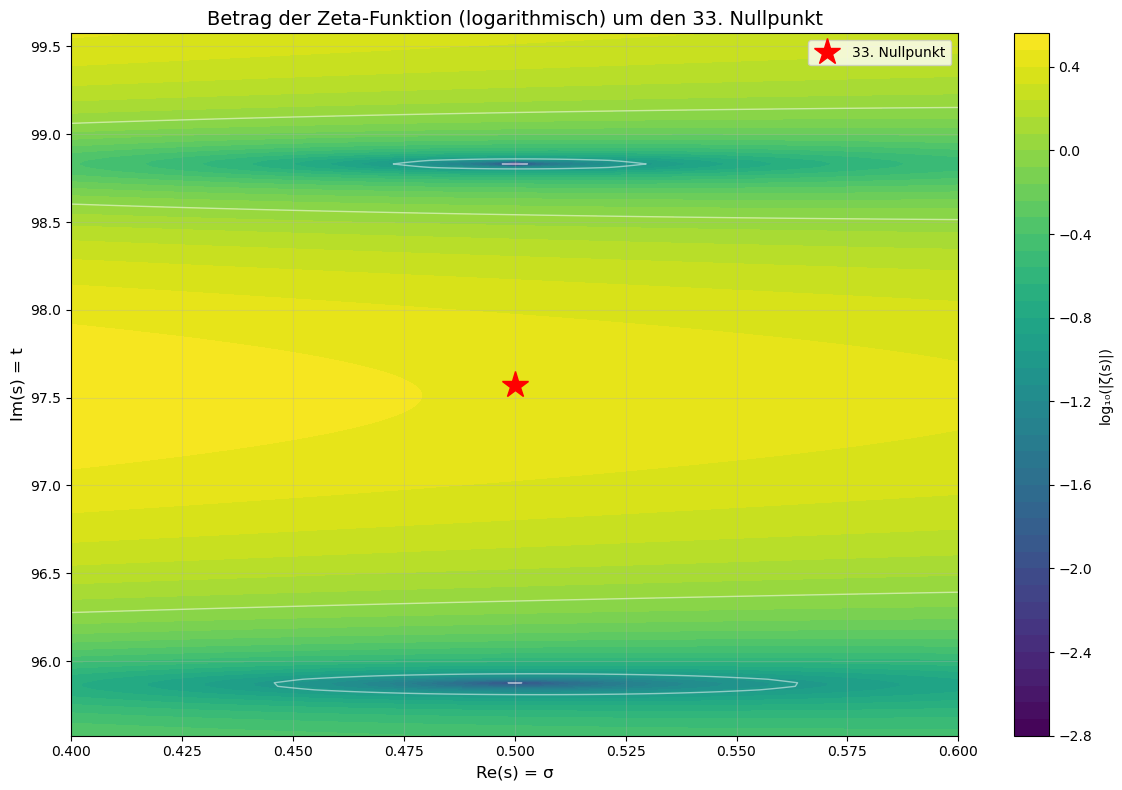

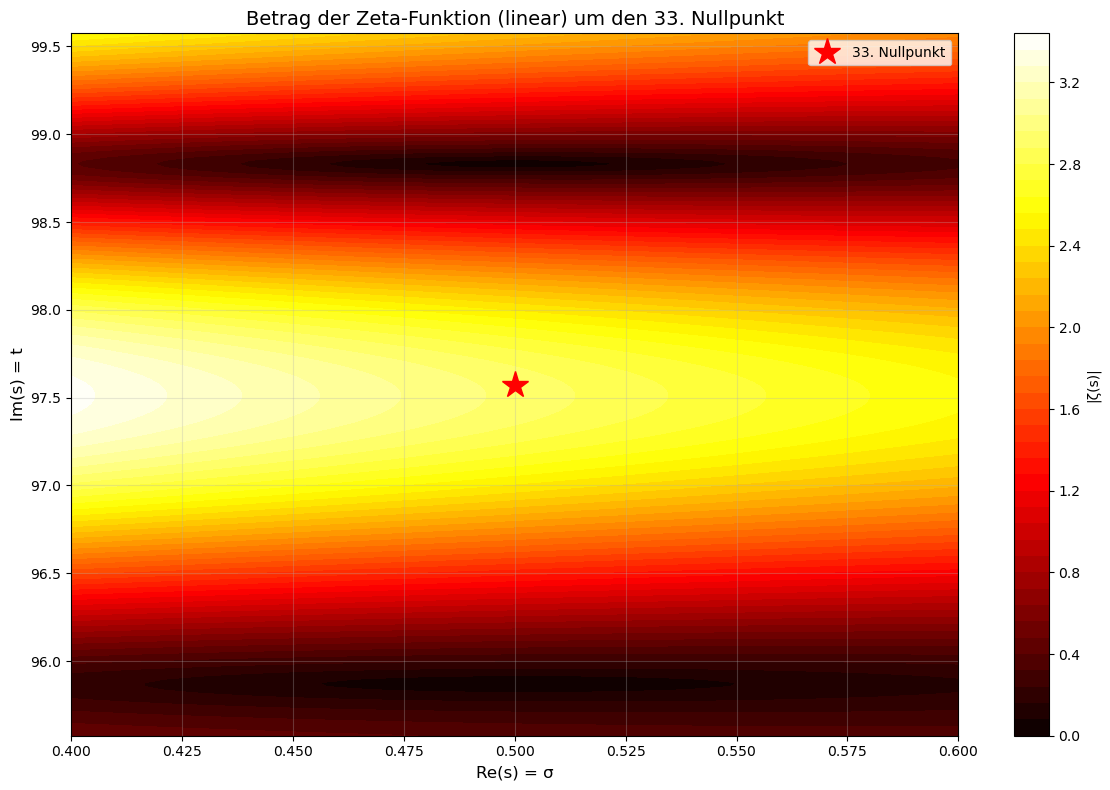

In [7]:
# Betrag der Zeta-Funktion (logarithmische Skala für bessere Visualisierung)
Zeta_abs_log = np.log10(Zeta_abs + 1e-10)  # + epsilon um log(0) zu vermeiden

plt.figure(figsize=(12, 8))
plt.contourf(Sigma, T, Zeta_abs_log, levels=50, cmap='viridis')
plt.colorbar(label='log₁₀(|ζ(s)|)')
plt.contour(Sigma, T, Zeta_abs, levels=[0.01, 0.1, 1, 10], colors='white', linewidths=1, alpha=0.5)
plt.plot(nullpunkt.real(), nullpunkt.imag(), 'r*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
plt.xlabel('Re(s) = σ', fontsize=12)
plt.ylabel('Im(s) = t', fontsize=12)
plt.title(f'Betrag der Zeta-Funktion (logarithmisch) um den {NULLPUNKT_NUMMER}. Nullpunkt', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Zusätzlich: Betrag in linearer Skala (Zoom auf kleine Werte)
plt.figure(figsize=(12, 8))
plt.contourf(Sigma, T, Zeta_abs, levels=50, cmap='hot')
plt.colorbar(label='|ζ(s)|')
plt.plot(nullpunkt.real(), nullpunkt.imag(), 'r*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
plt.xlabel('Re(s) = σ', fontsize=12)
plt.ylabel('Im(s) = t', fontsize=12)
plt.title(f'Betrag der Zeta-Funktion (linear) um den {NULLPUNKT_NUMMER}. Nullpunkt', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Phase (Argument) der Zeta-Funktion

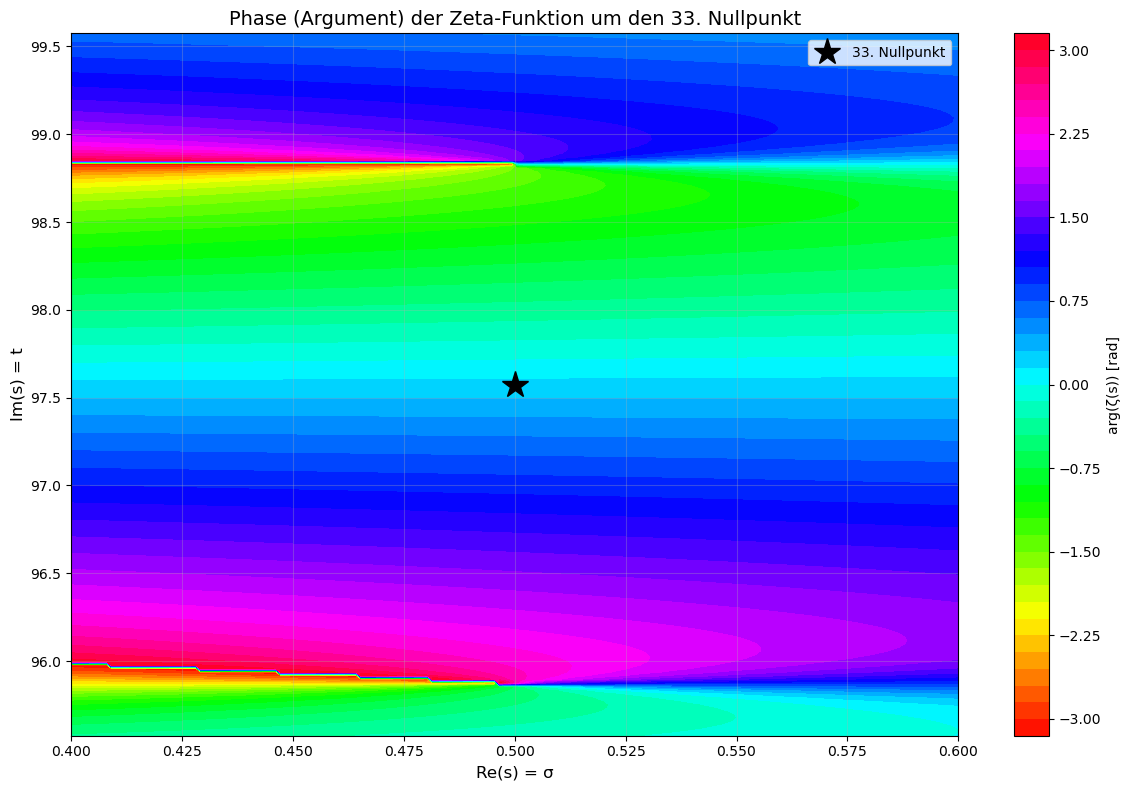

In [8]:
# Phase der Zeta-Funktion
plt.figure(figsize=(12, 8))
plt.contourf(Sigma, T, Zeta_arg, levels=50, cmap='hsv')
plt.colorbar(label='arg(ζ(s)) [rad]')
plt.plot(nullpunkt.real(), nullpunkt.imag(), 'k*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
plt.xlabel('Re(s) = σ', fontsize=12)
plt.ylabel('Im(s) = t', fontsize=12)
plt.title(f'Phase (Argument) der Zeta-Funktion um den {NULLPUNKT_NUMMER}. Nullpunkt', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 3D-Visualisierung des Betrags

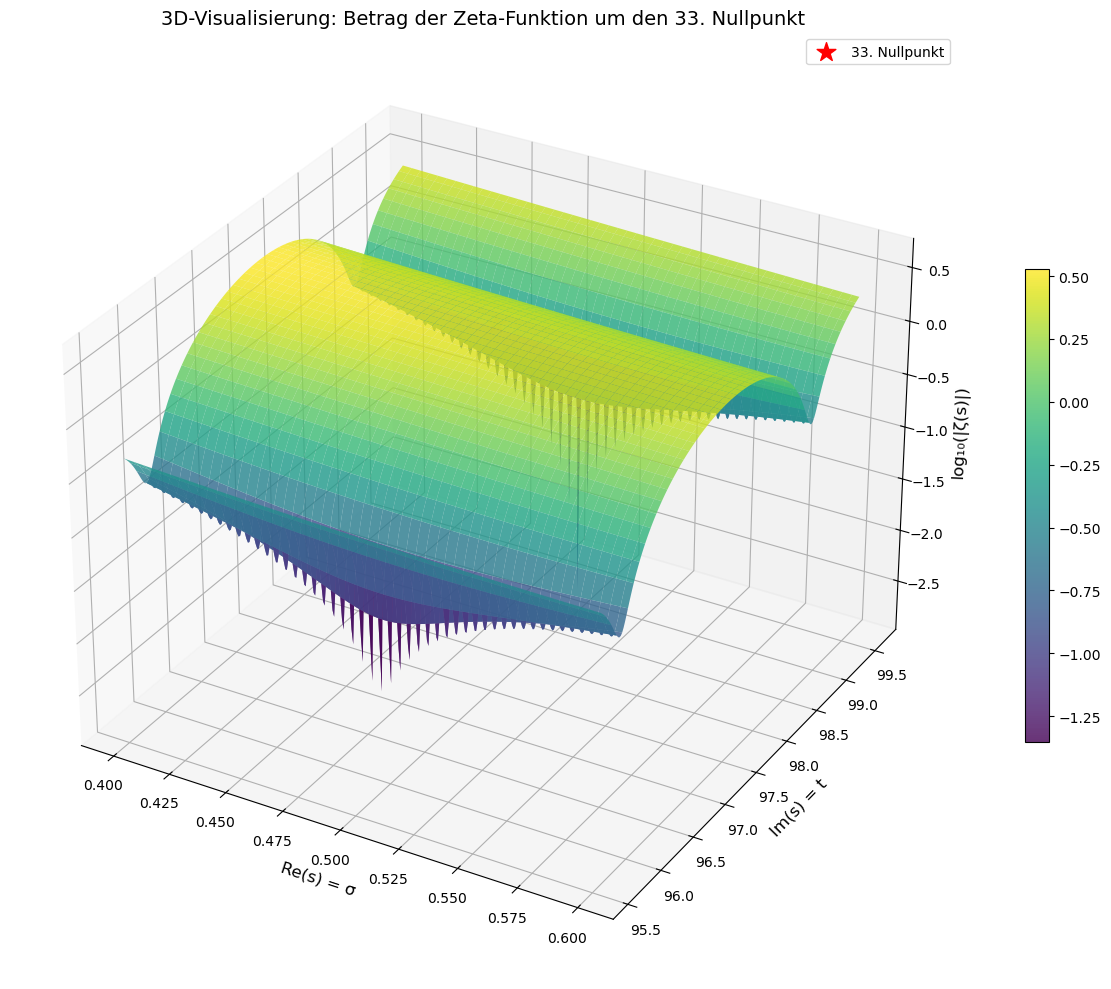

In [9]:
# 3D-Plot des Betrags (nur wenn PLOT_3D aktiviert)
if PLOT_3D:
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Verwende logarithmische Skala für bessere Visualisierung
    surf = ax.plot_surface(Sigma, T, Zeta_abs_log, cmap='viridis', 
                           alpha=0.8, linewidth=0, antialiased=True)
    
    # Markiere den Nullpunkt
    ax.scatter([nullpunkt.real()], [nullpunkt.imag()], 
              [np.log10(abs(zeta(nullpunkt)) + 1e-10)], 
              color='red', s=200, marker='*', label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
    
    ax.set_xlabel('Re(s) = σ', fontsize=12)
    ax.set_ylabel('Im(s) = t', fontsize=12)
    ax.set_zlabel('log₁₀(|ζ(s)|)', fontsize=12)
    ax.set_title(f'3D-Visualisierung: Betrag der Zeta-Funktion um den {NULLPUNKT_NUMMER}. Nullpunkt', 
                 fontsize=14)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5. Detaillierte Analyse: Schnitte durch den Nullpunkt

Untersuchen wir das Verhalten der Zeta-Funktion entlang verschiedener Schnitte durch den Nullpunkt.

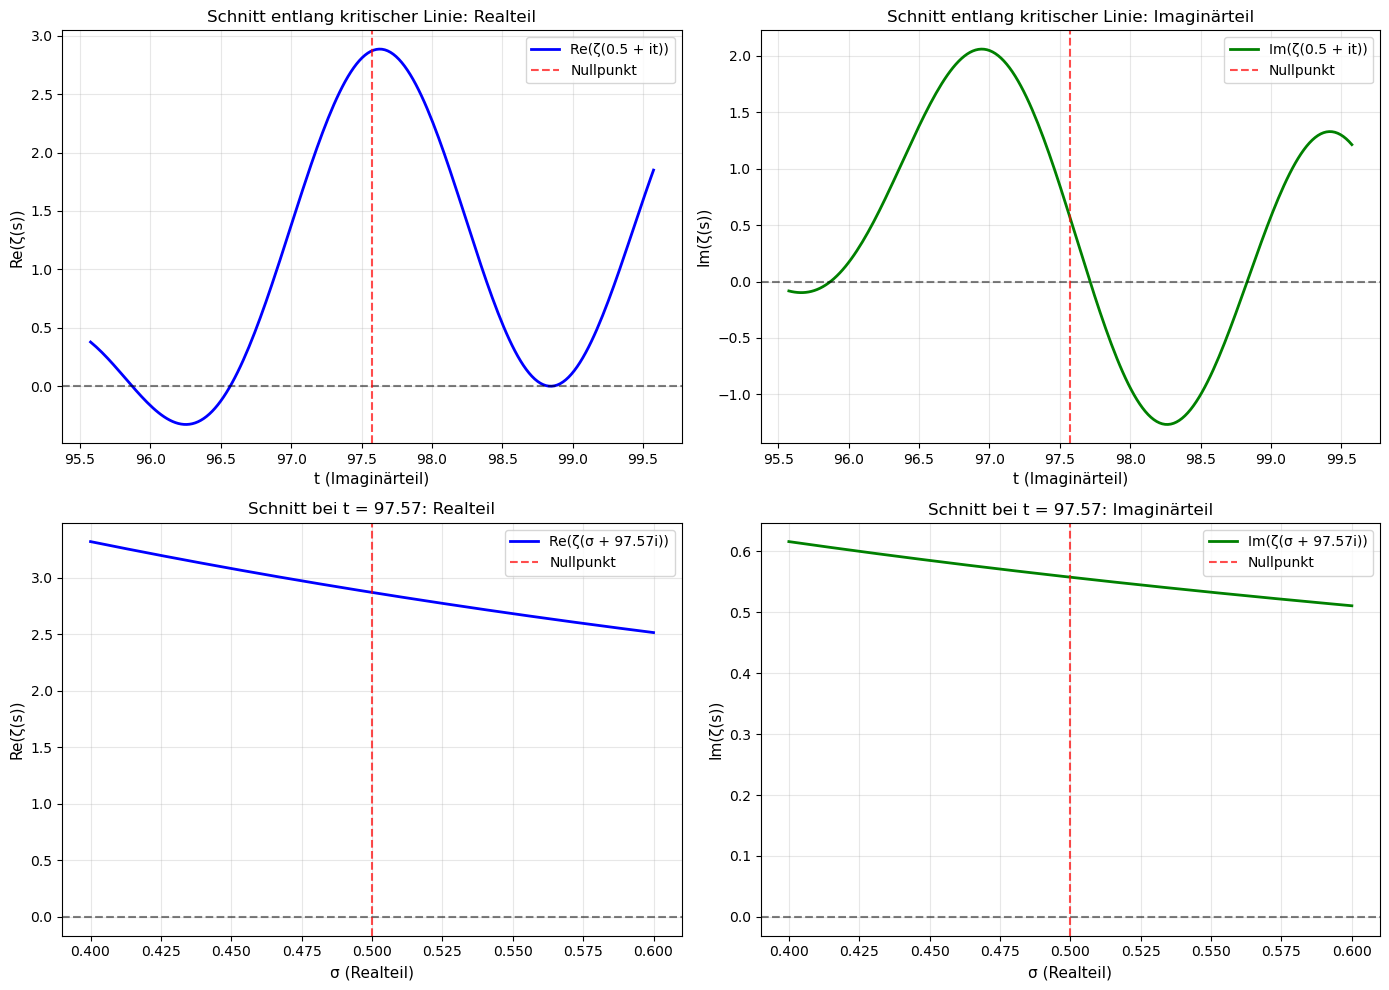

In [10]:
# ============================================================================
# SCHNITTE DURCH DEN NULLPUNKT
# ============================================================================

# Schnitt 1: Entlang der kritischen Linie (σ = 0.5)
t_schnitt = np.linspace(t_min, t_max, RESOLUTION)
# Konvertiere NumPy-Werte explizit zu Python-Floats für SageMath
zeta_kritisch = [zeta(0.5 + I*float(t)) for t in t_schnitt]
zeta_kritisch_real = [z.real() for z in zeta_kritisch]
zeta_kritisch_imag = [z.imag() for z in zeta_kritisch]
zeta_kritisch_abs = [abs(z) for z in zeta_kritisch]

# Schnitt 2: Entlang konstantem Imaginärteil (t = t₀)
sigma_schnitt = np.linspace(sigma_min, sigma_max, RESOLUTION)
# Konvertiere NumPy-Werte explizit zu Python-Floats für SageMath
t_nullpunkt = float(nullpunkt.imag())
zeta_horizontal = [zeta(float(sigma) + I*t_nullpunkt) for sigma in sigma_schnitt]
zeta_horizontal_real = [z.real() for z in zeta_horizontal]
zeta_horizontal_imag = [z.imag() for z in zeta_horizontal]
zeta_horizontal_abs = [abs(z) for z in zeta_horizontal]

# Visualisierung der Schnitte
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Kritische Linie: Realteil
axes[0, 0].plot(t_schnitt, zeta_kritisch_real, 'b-', linewidth=2, label='Re(ζ(0.5 + it))')
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=nullpunkt.imag(), color='r', linestyle='--', alpha=0.7, label='Nullpunkt')
axes[0, 0].set_xlabel('t (Imaginärteil)', fontsize=11)
axes[0, 0].set_ylabel('Re(ζ(s))', fontsize=11)
axes[0, 0].set_title('Schnitt entlang kritischer Linie: Realteil', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Kritische Linie: Imaginärteil
axes[0, 1].plot(t_schnitt, zeta_kritisch_imag, 'g-', linewidth=2, label='Im(ζ(0.5 + it))')
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=nullpunkt.imag(), color='r', linestyle='--', alpha=0.7, label='Nullpunkt')
axes[0, 1].set_xlabel('t (Imaginärteil)', fontsize=11)
axes[0, 1].set_ylabel('Im(ζ(s))', fontsize=11)
axes[0, 1].set_title('Schnitt entlang kritischer Linie: Imaginärteil', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Horizontaler Schnitt: Realteil
axes[1, 0].plot(sigma_schnitt, zeta_horizontal_real, 'b-', linewidth=2, label=f'Re(ζ(σ + {nullpunkt.imag():.2f}i))')
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=nullpunkt.real(), color='r', linestyle='--', alpha=0.7, label='Nullpunkt')
axes[1, 0].set_xlabel('σ (Realteil)', fontsize=11)
axes[1, 0].set_ylabel('Re(ζ(s))', fontsize=11)
axes[1, 0].set_title(f'Schnitt bei t = {nullpunkt.imag():.2f}: Realteil', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Horizontaler Schnitt: Imaginärteil
axes[1, 1].plot(sigma_schnitt, zeta_horizontal_imag, 'g-', linewidth=2, label=f'Im(ζ(σ + {nullpunkt.imag():.2f}i))')
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=nullpunkt.real(), color='r', linestyle='--', alpha=0.7, label='Nullpunkt')
axes[1, 1].set_xlabel('σ (Realteil)', fontsize=11)
axes[1, 1].set_ylabel('Im(ζ(s))', fontsize=11)
axes[1, 1].set_title(f'Schnitt bei t = {nullpunkt.imag():.2f}: Imaginärteil', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Nullstellen-Linien (Zero-Crossing Contours)

Visualisierung der Linien, entlang derer Realteil oder Imaginärteil Null sind.

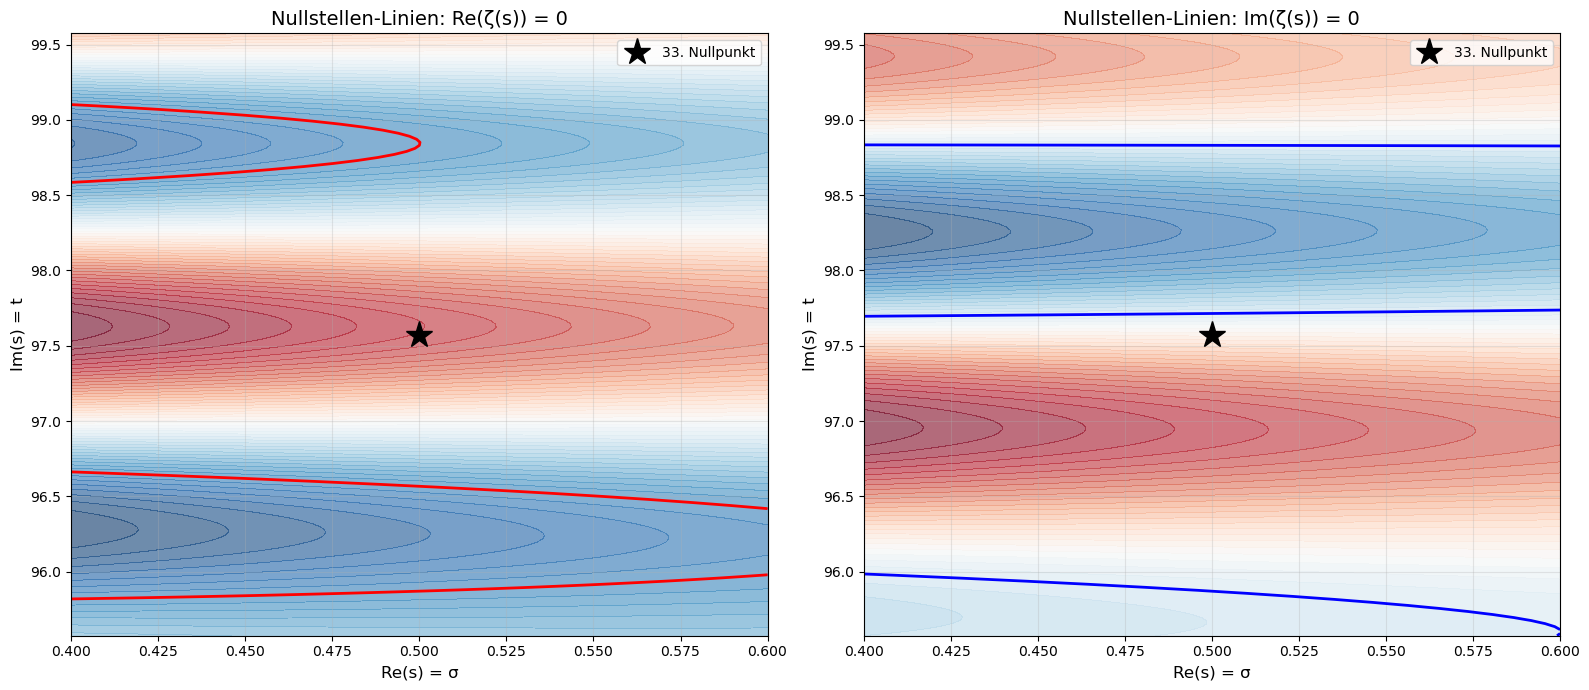

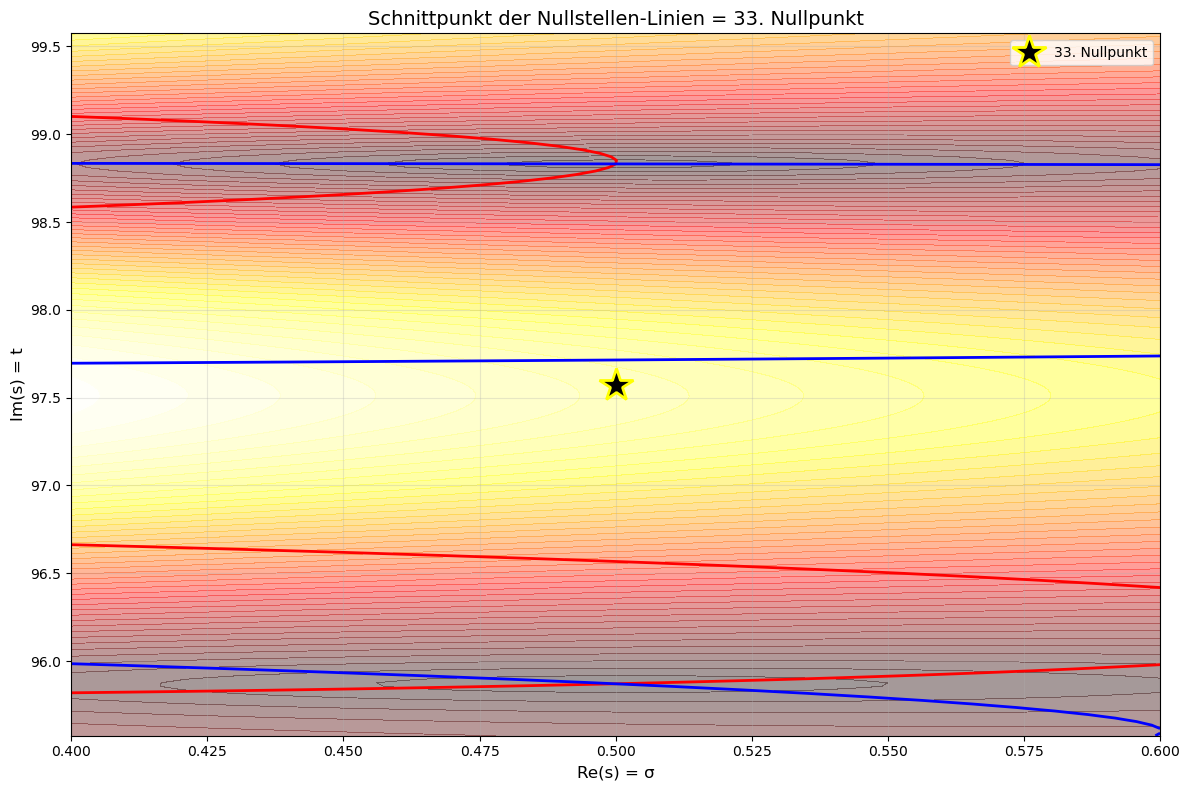

In [11]:
# Nullstellen-Linien
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Realteil = 0
CS1 = axes[0].contour(Sigma, T, Zeta_real, levels=[0], colors='red', linewidths=2)
axes[0].contourf(Sigma, T, Zeta_real, levels=50, cmap='RdBu_r', alpha=0.6)
axes[0].plot(nullpunkt.real(), nullpunkt.imag(), 'k*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
axes[0].set_xlabel('Re(s) = σ', fontsize=12)
axes[0].set_ylabel('Im(s) = t', fontsize=12)
axes[0].set_title('Nullstellen-Linien: Re(ζ(s)) = 0', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Imaginärteil = 0
CS2 = axes[1].contour(Sigma, T, Zeta_imag, levels=[0], colors='blue', linewidths=2)
axes[1].contourf(Sigma, T, Zeta_imag, levels=50, cmap='RdBu_r', alpha=0.6)
axes[1].plot(nullpunkt.real(), nullpunkt.imag(), 'k*', markersize=20, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
axes[1].set_xlabel('Re(s) = σ', fontsize=12)
axes[1].set_ylabel('Im(s) = t', fontsize=12)
axes[1].set_title('Nullstellen-Linien: Im(ζ(s)) = 0', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Kombinierte Darstellung: Schnittpunkt der Nullstellen-Linien = Nullpunkt
fig, ax = plt.subplots(figsize=(12, 8))
ax.contour(Sigma, T, Zeta_real, levels=[0], colors='red', linewidths=2, label='Re(ζ(s)) = 0')
ax.contour(Sigma, T, Zeta_imag, levels=[0], colors='blue', linewidths=2, label='Im(ζ(s)) = 0')
ax.contourf(Sigma, T, Zeta_abs, levels=50, cmap='hot', alpha=0.4)
ax.plot(nullpunkt.real(), nullpunkt.imag(), 'k*', markersize=25, 
        markeredgecolor='yellow', markeredgewidth=2, label=f'{NULLPUNKT_NUMMER}. Nullpunkt')
ax.set_xlabel('Re(s) = σ', fontsize=12)
ax.set_ylabel('Im(s) = t', fontsize=12)
ax.set_title(f'Schnittpunkt der Nullstellen-Linien = {NULLPUNKT_NUMMER}. Nullpunkt', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Numerische Eigenschaften am Nullpunkt

Berechnung von Ableitungen und anderen Eigenschaften am Nullpunkt.

In [12]:
# ============================================================================
# NUMERISCHE EIGENSCHAFTEN AM NULLPUNKT
# ============================================================================

# Berechne erste Ableitung am Nullpunkt (numerisch)
h = 1e-8
zeta_s0 = zeta(nullpunkt)
zeta_s0_plus_h_sigma = zeta(nullpunkt + h)
zeta_s0_plus_h_t = zeta(nullpunkt + I*h)

# Numerische Ableitungen
d_zeta_d_sigma = (zeta_s0_plus_h_sigma - zeta_s0) / h
d_zeta_d_t = (zeta_s0_plus_h_t - zeta_s0) / (I*h)

print("=" * 70)
print(f"NUMERISCHE EIGENSCHAFTEN AM {NULLPUNKT_NUMMER}. NULLPUNKT")
print("=" * 70)
print(f"\nNullpunkt: s₀ = {nullpunkt}")
print(f"  Re(s₀) = {nullpunkt.real():.10f}")
print(f"  Im(s₀) = {nullpunkt.imag():.10f}")

print(f"\nZeta-Funktion am Nullpunkt:")
print(f"  ζ(s₀) = {zeta_s0}")
print(f"  |ζ(s₀)| = {abs(zeta_s0):.2e}")

print(f"\nAbleitungen (numerisch):")
print(f"  ∂ζ/∂σ ≈ {d_zeta_d_sigma}")
print(f"  ∂ζ/∂t ≈ {d_zeta_d_t}")
print(f"  |∂ζ/∂σ| = {abs(d_zeta_d_sigma):.6f}")
print(f"  |∂ζ/∂t| = {abs(d_zeta_d_t):.6f}")

# Berechne auch die zweite Ableitung (für Krümmung)
zeta_s0_minus_h_sigma = zeta(nullpunkt - h)
d2_zeta_d_sigma2 = (zeta_s0_plus_h_sigma - 2*zeta_s0 + zeta_s0_minus_h_sigma) / (h**2)

print(f"\nZweite Ableitung:")
print(f"  ∂²ζ/∂σ² ≈ {d2_zeta_d_sigma2}")
print(f"  |∂²ζ/∂σ²| = {abs(d2_zeta_d_sigma2):.6f}")

# Berechne den Winkel, unter dem die Nullstellen-Linien sich schneiden
# Dies ist durch die Ableitungen gegeben
angle = arg(d_zeta_d_sigma / d_zeta_d_t)
angle_float = float(angle)  # Konvertiere zu Python-Float für Formatierung
angle_deg = float(angle * 180 / pi)  # Konvertiere Grad zu Float
print(f"\nGeometrische Eigenschaften:")
print(f"  Winkel zwischen Nullstellen-Linien: {angle_float:.6f} rad = {angle_deg:.2f}°")

print("\n" + "=" * 70)

NUMERISCHE EIGENSCHAFTEN AM 33. NULLPUNKT

Nullpunkt: s₀ = 0.500000000000000 + 97.5748000000000*I
  Re(s₀) = 0.5000000000
  Im(s₀) = 97.5748000000

Zeta-Funktion am Nullpunkt:
  ζ(s₀) = 2.87207839659363 + 0.557203556434932*I
  |ζ(s₀)| = 2.93e+0

Ableitungen (numerisch):
  ∂ζ/∂σ ≈ -3.98608079876794 - 0.519801479637039*I
  ∂ζ/∂t ≈ -3.98607830076614 - 0.519801091058980*I
  |∂ζ/∂σ| = 4.019830
  |∂ζ/∂t| = 4.019828

Zweite Ableitung:
  ∂²ζ/∂σ² ≈ 4.44089209850063 + 2.22044604925031*I
  |∂²ζ/∂σ²| = 4.965068

Geometrische Eigenschaften:
  Winkel zwischen Nullstellen-Linien: 0.000000 rad = 0.00°



## 8. Interaktive Kontrolle (Optional)

Für interaktive Anpassungen können Sie die Parameter in Zelle 5 ändern und die Berechnungen erneut ausführen.

**Hinweise zur Nutzung:**
- Ändern Sie `NULLPUNKT_NUMMER` in Zelle 3, um einen anderen Nullpunkt zu untersuchen
- Passen Sie `DELTA_SIGMA` und `DELTA_T` in Zelle 5 an, um den Untersuchungsbereich zu ändern
- Erhöhen Sie `RESOLUTION` für höhere Genauigkeit (aber längere Berechnungszeit)
- Aktivieren/Deaktivieren Sie die Plot-Optionen in Zelle 5